<a href="https://colab.research.google.com/github/LeeHJ030417/Machine-Learning-Course-Project/blob/main/%EA%B8%B0%EA%B3%84%ED%95%99%EC%8A%B5_26_05_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AG News Classifier — FINAL (NameError-resistant version)

## 사용법 (반드시 순서대로 한 번 실행)
1. **Cell 1** : 패키지 설치  (런타임 재시작 후에도 한 번 실행)
2. **Cell 2** : 임포트 + 전역 설정
3. **Cell 3** : 데이터 로딩 → 디스크 저장
4. **Cell 4** : 모델 클래스 정의
5. **Cell 5** : 학습 + 체크포인트 저장 (~30~45분)
6. **Cell 6~11** : 평가 / 분석 — 순서 상관없이 실행 가능 (자동 복구 기능 포함)

**런타임 재시작 시**: Cell 1~4 만 다시 실행하면 됨. 학습한 체크포인트는 자동 복구.

In [ ]:
# 매 세션 한 번만 실행. 실행 후 런타임 재시작 권장.
!pip install -q datasets transformers accelerate scikit-learn \
             torch matplotlib seaborn tqdm joblib

In [ ]:
import os, re, random, string, urllib.request, warnings, pickle, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score,
                              confusion_matrix, classification_report)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

import transformers
from transformers import (DistilBertTokenizerFast,
                           DistilBertForSequenceClassification,
                           get_linear_schedule_with_warmup)

warnings.filterwarnings('ignore')
transformers.logging.set_verbosity_error()

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

# ── 전역 상수 ────────────────────────────────────────────────────────────────
CLASSES     = ['World', 'Sports', 'Business', 'Sci/Tech']
NUM_CLASSES = 4
TEXT_COL    = 'title_desc'              # 메인 input column
LABEL_COL   = 'label'                   # 라벨 column 이름
INPUT_MODES = ['title', 'description', 'title_desc']

# ── 저장 경로 ────────────────────────────────────────────────────────────────
DATA_DIR    = '/content/data'
CKPT_DIR    = '/content/checkpoints'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

DF_PATH     = os.path.join(DATA_DIR, 'dataframes.pkl')
TFIDF_PATH  = lambda mode: os.path.join(CKPT_DIR, f'tfidf_{mode}.joblib')
CNN_PATH    = lambda mode: os.path.join(CKPT_DIR, f'cnn_{mode}.pt')
CNN_TOK_PATH= lambda mode: os.path.join(CKPT_DIR, f'cnn_tok_{mode}.pkl')
BERT_PATH   = lambda mode: os.path.join(CKPT_DIR, f'bert_{mode}.pt')

print("Setup complete. Paths:")
print(f"  DATA_DIR = {DATA_DIR}")
print(f"  CKPT_DIR = {CKPT_DIR}")

Device : cuda
GPU    : NVIDIA A100-SXM4-40GB
Setup complete. Paths:
  DATA_DIR = /content/data
  CKPT_DIR = /content/checkpoints


In [ ]:
TRAIN_CSV = os.path.join(DATA_DIR, 'ag_train.csv')
TEST_CSV  = os.path.join(DATA_DIR, 'ag_test.csv')
TRAIN_URL = ("https://raw.githubusercontent.com/"
             "mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv")
TEST_URL  = ("https://raw.githubusercontent.com/"
             "mhjabreel/CharCnn_Keras/master/data/ag_news_csv/test.csv")

if not os.path.exists(TRAIN_CSV):
    print("Downloading train.csv ..."); urllib.request.urlretrieve(TRAIN_URL, TRAIN_CSV)
if not os.path.exists(TEST_CSV):
    print("Downloading test.csv  ..."); urllib.request.urlretrieve(TEST_URL,  TEST_CSV)


def _clean_text(t):
    t = re.sub(r'[^A-Za-z0-9\s(),!?]', ' ', str(t))
    t = re.sub(r'\s{2,}', ' ', t)
    return t.strip().lower()


def _load_csv(path):
    df = pd.read_csv(path, header=None, names=[LABEL_COL, 'title', 'description'])
    df[LABEL_COL] = df[LABEL_COL] - 1                       # 0-indexed
    df['title']       = df['title'].fillna('').apply(_clean_text)
    df['description'] = df['description'].fillna('').apply(_clean_text)
    df['title_desc']  = (df['title'] + ' ' + df['description']).str.strip()
    return df


# 이미 디스크에 저장돼 있으면 그대로 로드 (런타임 재시작 후에도 빠르게 복구)
if os.path.exists(DF_PATH):
    print(f"Loading existing dataframes from {DF_PATH} ...")
    with open(DF_PATH, 'rb') as f:
        _bundle = pickle.load(f)
    train_df = _bundle['train']
    val_df   = _bundle['val']
    test_df  = _bundle['test']
else:
    print("Building dataframes from CSV ...")
    full_train = _load_csv(TRAIN_CSV)
    test_df    = _load_csv(TEST_CSV)
    train_df, val_df = train_test_split(
        full_train, test_size=0.10, random_state=SEED,
        stratify=full_train[LABEL_COL],
    )
    train_df = train_df.reset_index(drop=True)
    val_df   = val_df.reset_index(drop=True)
    with open(DF_PATH, 'wb') as f:
        pickle.dump({'train': train_df, 'val': val_df, 'test': test_df}, f)
    print(f"Saved dataframes → {DF_PATH}")

print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}")
print(train_df.head(2).to_string())

Building dataframes from CSV ...
Saved dataframes → /content/data/dataframes.pkl
Train: 108,000  |  Val: 12,000  |  Test: 7,600
   label                                title                                                                                                                                                                                                                                          description                                                                                                                                                                                                                                                                             title_desc
0      1    10 seconds that change everything  athens ten seconds barely time enough to tie a shoe, wash a glass, get the paper off the porch but when the moment comes, and eight men kneel at their blocks and peer down the empty, waiting track, it is as if the entire olympics stop to watch  10 seconds

In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# (1) Metric helper
# (2) TfidfLogReg
# (3) TextCNN (with tokenizer + dataset)
# (4) DistilBertClassifier
# ──────────────────────────────────────────────────────────────────────────────

# ──────────────── Shared metric helper ────────────────
def compute_metrics(labels, preds):
    labels = list(labels); preds = list(preds)
    return {
        'acc':      accuracy_score(labels, preds),
        'macro_f1': f1_score(labels, preds, average='macro'),
        'per_f1':   f1_score(labels, preds, average=None),
        'preds':    np.array(preds),
    }


# ──────────────── (1) TF-IDF + LR ────────────────
def build_tfidf_pipeline():
    return Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=50_000, ngram_range=(1, 2),
            sublinear_tf=True, strip_accents='unicode',
        )),
        ('clf', LogisticRegression(
            C=5.0, max_iter=1000, solver='lbfgs',
            multi_class='multinomial', random_state=SEED, n_jobs=-1,
        )),
    ])


def train_tfidf_lr(texts, labels):
    pipe = build_tfidf_pipeline()
    pipe.fit(texts, labels)
    return pipe


def predict_tfidf(pipe, texts):
    return pipe.predict(texts)


def predict_proba_tfidf(pipe, texts):
    return pipe.predict_proba(texts)


# ──────────────── (2) TextCNN ────────────────
CNN_MAX_LEN       = 200
CNN_EMBEDDING_DIM = 100
CNN_N_FILTERS     = 100
CNN_FILTER_SIZES  = [3, 4, 5]
CNN_DROPOUT       = 0.5
CNN_BATCH_SIZE    = 64
CNN_N_EPOCHS      = 5
CNN_LR            = 1e-3


class CNNTokenizer:
    def __init__(self, texts=None, min_freq=5):
        self.word_to_idx = {'<unk>': 0, '<pad>': 1}
        if texts is not None:
            counts = Counter(w for t in texts for w in t.split())
            for word, cnt in counts.items():
                if cnt >= min_freq:
                    self.word_to_idx[word] = len(self.word_to_idx)

    @property
    def vocab_size(self):
        return len(self.word_to_idx)

    def encode(self, text, max_len):
        ids  = [self.word_to_idx.get(w, 0) for w in text.split()[:max_len]]
        ids += [1] * (max_len - len(ids))
        return torch.tensor(ids, dtype=torch.long)


class CNNDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.data = [
            {'input_ids': tokenizer.encode(t, max_len),
             'labels':    torch.tensor(l, dtype=torch.long)}
            for t, l in zip(texts, labels)
        ]

    def __len__(self):        return len(self.data)
    def __getitem__(self, i): return self.data[i]


class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=CNN_EMBEDDING_DIM,
                 n_filters=CNN_N_FILTERS, filter_sizes=CNN_FILTER_SIZES,
                 n_classes=NUM_CLASSES, dropout=CNN_DROPOUT, pad_idx=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.convs = nn.ModuleList([
            nn.Conv2d(1, n_filters, (fs, embed_dim)) for fs in filter_sizes
        ])
        self.fc      = nn.Linear(len(filter_sizes) * n_filters, n_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        emb = self.embedding(x).unsqueeze(1)
        pooled = []
        for conv in self.convs:
            c = F.relu(conv(emb)).squeeze(3)
            p = F.max_pool1d(c, c.size(2)).squeeze(2)
            pooled.append(p)
        return self.fc(self.dropout(torch.cat(pooled, dim=1)))


def train_cnn(texts, labels, val_texts=None, val_labels=None,
              tokenizer=None, max_len=CNN_MAX_LEN, epochs=CNN_N_EPOCHS):
    if tokenizer is None:
        tokenizer = CNNTokenizer(texts, min_freq=5)
    tr_loader = DataLoader(CNNDataset(texts, labels, tokenizer, max_len),
                           batch_size=CNN_BATCH_SIZE, shuffle=True,  num_workers=2)
    val_loader = None
    if val_texts is not None:
        val_loader = DataLoader(CNNDataset(val_texts, val_labels, tokenizer, max_len),
                                 batch_size=CNN_BATCH_SIZE, shuffle=False, num_workers=2)

    model = TextCNN(tokenizer.vocab_size).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=CNN_LR)
    criterion = nn.CrossEntropyLoss()
    best_f1, best_state = 0.0, None

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = total_acc = 0.0
        for batch in tqdm(tr_loader, desc=f'  [CNN] Ep {epoch}/{epochs}', leave=False):
            ids = batch['input_ids'].to(DEVICE); ys = batch['labels'].to(DEVICE)
            optimizer.zero_grad()
            out = model(ids); loss = criterion(out, ys)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
            total_acc  += (out.argmax(1) == ys).float().mean().item()
        msg = f'  Ep {epoch}: loss={total_loss/len(tr_loader):.4f} acc={total_acc/len(tr_loader):.4f}'

        if val_loader is not None:
            v = eval_cnn(model, val_loader)
            msg += f'  val_acc={v["acc"]:.4f}  val_f1={v["macro_f1"]:.4f}'
            if v['macro_f1'] > best_f1:
                best_f1 = v['macro_f1']
                best_state = {k: t.clone() for k, t in model.state_dict().items()}
        print(msg)

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f'  ✓ Best val Macro-F1: {best_f1:.4f}')
    return model, tokenizer


def eval_cnn(model, loader, get_probs=False):
    model.eval()
    preds, labels, probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            ids = batch['input_ids'].to(DEVICE); ys = batch['labels'].to(DEVICE)
            out = model(ids)
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(ys.cpu().numpy())
            if get_probs:
                probs.extend(F.softmax(out, dim=1).cpu().numpy())
    r = compute_metrics(labels, preds)
    if get_probs:
        r['probs'] = np.array(probs)
    return r


def predict_cnn(model, texts, tokenizer, max_len):
    ds = CNNDataset(texts, [0]*len(texts), tokenizer, max_len)
    loader = DataLoader(ds, batch_size=CNN_BATCH_SIZE, shuffle=False, num_workers=2)
    return eval_cnn(model, loader, get_probs=True)


# ──────────────── (3) DistilBERT ────────────────
BERT_MODEL      = 'distilbert-base-uncased'
BERT_MAX_LEN    = 128
BERT_BATCH_SIZE = 16
BERT_N_EPOCHS   = 3
BERT_LR         = 2e-5

# tokenizer는 전역에서 1회만 로드 (재학습/평가 모두 공유)
bert_tokenizer = DistilBertTokenizerFast.from_pretrained(BERT_MODEL)


class BertDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=BERT_MAX_LEN):
        enc = tokenizer(list(texts), max_length=max_len, truncation=True,
                        padding='max_length', return_tensors='pt')
        self.input_ids      = enc['input_ids']
        self.attention_mask = enc['attention_mask']
        self.labels         = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        return {'input_ids': self.input_ids[i],
                'attention_mask': self.attention_mask[i],
                'labels': self.labels[i]}


def build_bert_model():
    return DistilBertForSequenceClassification.from_pretrained(
        BERT_MODEL, num_labels=NUM_CLASSES
    ).to(DEVICE)


def train_bert(texts, labels, val_texts=None, val_labels=None,
               epochs=BERT_N_EPOCHS):
    model = build_bert_model()
    tr_loader = DataLoader(BertDataset(texts, labels, bert_tokenizer),
                           batch_size=BERT_BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=True)
    total_steps = len(tr_loader) * epochs
    optimizer = optim.AdamW(model.parameters(), lr=BERT_LR, weight_decay=0.01)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=total_steps//10, num_training_steps=total_steps,
    )
    best_f1, best_state = 0.0, None

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for batch in tqdm(tr_loader, desc=f'  [BERT] Ep {epoch}/{epochs}', leave=False):
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            ys   = batch['labels'].to(DEVICE)
            out  = model(input_ids=ids, attention_mask=mask, labels=ys)
            optimizer.zero_grad()
            out.loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step()
            total_loss += out.loss.item()
        msg = f'  Ep {epoch}: loss={total_loss/len(tr_loader):.4f}'
        if val_texts is not None:
            v = predict_bert(model, val_texts, val_labels)
            msg += f'  val_acc={v["acc"]:.4f}  val_f1={v["macro_f1"]:.4f}'
            if v['macro_f1'] > best_f1:
                best_f1 = v['macro_f1']
                best_state = {k: t.clone() for k, t in model.state_dict().items()}
        print(msg)

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f'  ✓ Best val Macro-F1: {best_f1:.4f}')
    return model


def predict_bert(model, texts, labels=None, batch_size=64, get_probs=True):
    if labels is None:
        labels = [0]*len(texts)
    ds = BertDataset(texts, labels, bert_tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2)
    model.eval()
    preds, ls, probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            logits = model(input_ids=batch['input_ids'].to(DEVICE),
                           attention_mask=batch['attention_mask'].to(DEVICE)).logits
            preds.extend(logits.argmax(1).cpu().numpy())
            ls.extend(batch['labels'].numpy())
            if get_probs:
                probs.extend(F.softmax(logits, dim=1).cpu().numpy())
    r = compute_metrics(ls, preds)
    if get_probs:
        r['probs'] = np.array(probs)
    return r

print("✓ All model classes loaded.")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✓ All model classes loaded.


In [ ]:
# ── 한 번만 실행하면 디스크에 저장됨. 이후 분석 셀은 자동으로 로드.
# ── 시간: TF-IDF ~3분, TextCNN ~10분, DistilBERT ~30~45분 (A100 기준)

assert 'train_df' in dir(), "❌ Cell 3 (데이터 로딩) 을 먼저 실행하세요."

trained_models = {}   # mode → {'tfidf':..., 'cnn':..., 'cnn_tok':..., 'cnn_maxlen':..., 'bert':...}

for mode in INPUT_MODES:
    print(f"\n{'='*60}\n  Training mode = {mode}\n{'='*60}")
    bundle = {}
    tr_texts  = train_df[mode].tolist()
    tr_labels = train_df[LABEL_COL].tolist()
    vl_texts  = val_df[mode].tolist()
    vl_labels = val_df[LABEL_COL].tolist()

    # ── TF-IDF ─────────────────────────────────────
    p = TFIDF_PATH(mode)
    if os.path.exists(p):
        print(f"  [TFIDF]  load {p}")
        bundle['tfidf'] = joblib.load(p)
    else:
        print(f"  [TFIDF]  training ...")
        bundle['tfidf'] = train_tfidf_lr(tr_texts, tr_labels)
        joblib.dump(bundle['tfidf'], p)
        print(f"  [TFIDF]  saved → {p}")

    # ── TextCNN ────────────────────────────────────
    cp, tp = CNN_PATH(mode), CNN_TOK_PATH(mode)
    raw_max = max(len(t.split()) for t in tr_texts + test_df[mode].tolist())
    cnn_maxlen = min(raw_max, CNN_MAX_LEN)
    if os.path.exists(cp) and os.path.exists(tp):
        print(f"  [CNN]    load {cp}")
        with open(tp, 'rb') as f:
            cnn_tok = pickle.load(f)
        cnn_model = TextCNN(cnn_tok.vocab_size).to(DEVICE)
        cnn_model.load_state_dict(torch.load(cp, map_location=DEVICE))
    else:
        print(f"  [CNN]    training ...")
        cnn_model, cnn_tok = train_cnn(tr_texts, tr_labels,
                                        vl_texts, vl_labels,
                                        max_len=cnn_maxlen)
        torch.save(cnn_model.state_dict(), cp)
        with open(tp, 'wb') as f:
            pickle.dump(cnn_tok, f)
        print(f"  [CNN]    saved → {cp}")
    bundle['cnn']         = cnn_model
    bundle['cnn_tok']     = cnn_tok
    bundle['cnn_maxlen']  = cnn_maxlen

    # ── DistilBERT ─────────────────────────────────
    bp = BERT_PATH(mode)
    if os.path.exists(bp):
        print(f"  [BERT]   load {bp}")
        bert = build_bert_model()
        bert.load_state_dict(torch.load(bp, map_location=DEVICE))
    else:
        print(f"  [BERT]   training ...")
        bert = train_bert(tr_texts, tr_labels, vl_texts, vl_labels)
        torch.save(bert.state_dict(), bp)
        print(f"  [BERT]   saved → {bp}")
    bundle['bert'] = bert

    trained_models[mode] = bundle

print(f"\n{'='*60}\nAll models ready. Modes trained: {list(trained_models.keys())}\n{'='*60}")


  Training mode = title
  [TFIDF]  training ...
  [TFIDF]  saved → /content/checkpoints/tfidf_title.joblib
  [CNN]    training ...


  [CNN] Ep 1/5:   0%|          | 0/1688 [00:00<?, ?it/s]

  Ep 1: loss=0.8870 acc=0.6381  val_acc=0.7958  val_f1=0.7958


  [CNN] Ep 2/5:   0%|          | 0/1688 [00:00<?, ?it/s]

  Ep 2: loss=0.5210 acc=0.8144  val_acc=0.8423  val_f1=0.8418


...

  Ep 1: loss=0.3101  val_acc=0.9366  val_f1=0.9366


  [BERT] Ep 2/3:   0%|          | 0/6750 [00:00<?, ?it/s]

  Ep 2: loss=0.1624  val_acc=0.9423  val_f1=0.9423


  [BERT] Ep 3/3:   0%|          | 0/6750 [00:00<?, ?it/s]

  Ep 3: loss=0.1064  val_acc=0.9429  val_f1=0.9429
  ✓ Best val Macro-F1: 0.9429
  [BERT]   saved → /content/checkpoints/bert_title_desc.pt

All models ready. Modes trained: ['title', 'description', 'title_desc']


In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# 이 셀은 NameError 방지를 위해 누락된 객체를 자동으로 디스크에서 로드합니다.
# 런타임이 재시작되어도 Cell 1~4 만 실행한 뒤 이 셀을 돌리면 모든 모델 복구.
# ──────────────────────────────────────────────────────────────────────────────

def _ensure_data():
    """누락 시 dataframes 자동 로드."""
    global train_df, val_df, test_df
    if 'train_df' not in globals() or 'test_df' not in globals():
        print("⚠ DataFrames missing → reloading from disk ...")
        with open(DF_PATH, 'rb') as f:
            b = pickle.load(f)
        train_df, val_df, test_df = b['train'], b['val'], b['test']


def _ensure_models():
    """누락 시 모든 모델 자동 로드."""
    global trained_models
    if 'trained_models' in globals() and len(trained_models) == len(INPUT_MODES):
        return
    print("⚠ trained_models missing → reloading from checkpoints ...")
    trained_models = {}
    for mode in INPUT_MODES:
        b = {}
        b['tfidf'] = joblib.load(TFIDF_PATH(mode))
        with open(CNN_TOK_PATH(mode), 'rb') as f:
            b['cnn_tok'] = pickle.load(f)
        b['cnn'] = TextCNN(b['cnn_tok'].vocab_size).to(DEVICE)
        b['cnn'].load_state_dict(torch.load(CNN_PATH(mode), map_location=DEVICE))
        # max_len 재계산
        raw_max = max(len(t.split()) for t in train_df[mode].tolist() + test_df[mode].tolist())
        b['cnn_maxlen'] = min(raw_max, CNN_MAX_LEN)
        b['bert'] = build_bert_model()
        b['bert'].load_state_dict(torch.load(BERT_PATH(mode), map_location=DEVICE))
        trained_models[mode] = b
    print(f"  ✓ Restored modes: {list(trained_models.keys())}")


def get_model_bundle(mode):
    """안전한 모델 접근. 누락 시 자동 복구."""
    _ensure_data()
    _ensure_models()
    return trained_models[mode]


# ── Evaluate all 9 combinations (3 models × 3 input modes) ────────────────
_ensure_data(); _ensure_models()

all_results = defaultdict(dict)   # (model_name, mode) → metrics dict

for mode in INPUT_MODES:
    b = trained_models[mode]
    te_texts  = test_df[mode].tolist()
    te_labels = test_df[LABEL_COL].tolist()

    # TF-IDF + LR
    probs = b['tfidf'].predict_proba(te_texts)
    preds = np.argmax(probs, axis=1)
    r = compute_metrics(te_labels, preds); r['probs'] = probs
    all_results['TF-IDF+LR'][mode] = r
    print(f"[TFIDF+LR  | {mode}]  Acc={r['acc']:.4f}  Macro-F1={r['macro_f1']:.4f}")

    # TextCNN
    r = predict_cnn(b['cnn'], te_texts, b['cnn_tok'], b['cnn_maxlen'])
    # predict_cnn returns labels=[0]*N → fix true labels
    r = compute_metrics(te_labels, r['preds'])
    r['probs'] = predict_cnn(b['cnn'], te_texts, b['cnn_tok'], b['cnn_maxlen'])['probs']
    all_results['TextCNN'][mode] = r
    print(f"[TextCNN   | {mode}]  Acc={r['acc']:.4f}  Macro-F1={r['macro_f1']:.4f}")

    # DistilBERT
    r = predict_bert(b['bert'], te_texts, te_labels, get_probs=True)
    all_results['DistilBERT'][mode] = r
    print(f"[DistilBERT| {mode}]  Acc={r['acc']:.4f}  Macro-F1={r['macro_f1']:.4f}")

# ── 편의를 위한 별칭 (이후 셀에서 사용) ───────────────────────────────────
tfidf_results      = all_results['TF-IDF+LR']
textcnn_results    = all_results['TextCNN']
distilbert_results = all_results['DistilBERT']

# 모델별 확률 — TEXT_COL(title_desc) 기준
trained_probs = {
    'TF-IDF+LR' : tfidf_results[TEXT_COL]['probs'],
    'TextCNN'   : textcnn_results[TEXT_COL]['probs'],
    'DistilBERT': distilbert_results[TEXT_COL]['probs'],
}

print("\n✓ Evaluation complete.  Vars defined: all_results, tfidf_results, textcnn_results, distilbert_results, trained_probs")

[TFIDF+LR  | title]  Acc=0.8726  Macro-F1=0.8724
[TextCNN   | title]  Acc=0.8584  Macro-F1=0.8577
[DistilBERT| title]  Acc=0.9038  Macro-F1=0.9037
[TFIDF+LR  | description]  Acc=0.9075  Macro-F1=0.9073
[TextCNN   | description]  Acc=0.8957  Macro-F1=0.8956
[DistilBERT| description]  Acc=0.9372  Macro-F1=0.9373
[TFIDF+LR  | title_desc]  Acc=0.9196  Macro-F1=0.9195
[TextCNN   | title_desc]  Acc=0.9093  Macro-F1=0.9092
[DistilBERT| title_desc]  Acc=0.9416  Macro-F1=0.9416

✓ Evaluation complete.  Vars defined: all_results, tfidf_results, textcnn_results, distilbert_results, trained_probs


     Model       Input  Accuracy  Macro-F1  F1-World  F1-Sports  F1-Business  F1-Sci/Tech
 TF-IDF+LR       title    0.8726    0.8724    0.8775     0.9147       0.8434       0.8539
   TextCNN       title    0.8584    0.8577    0.8655     0.9000       0.8243       0.8411
DistilBERT       title    0.9038    0.9037    0.9113     0.9464       0.8709       0.8862
 TF-IDF+LR description    0.9075    0.9073    0.9132     0.9622       0.8715       0.8825
   TextCNN description    0.8957    0.8956    0.8971     0.9559       0.8600       0.8693
DistilBERT description    0.9372    0.9373    0.9499     0.9808       0.9072       0.9112
 TF-IDF+LR  title_desc    0.9196    0.9195    0.9196     0.9692       0.8878       0.9012
   TextCNN  title_desc    0.9093    0.9092    0.9138     0.9616       0.8754       0.8861
DistilBERT  title_desc    0.9416    0.9416    0.9509     0.9832       0.9144       0.9178


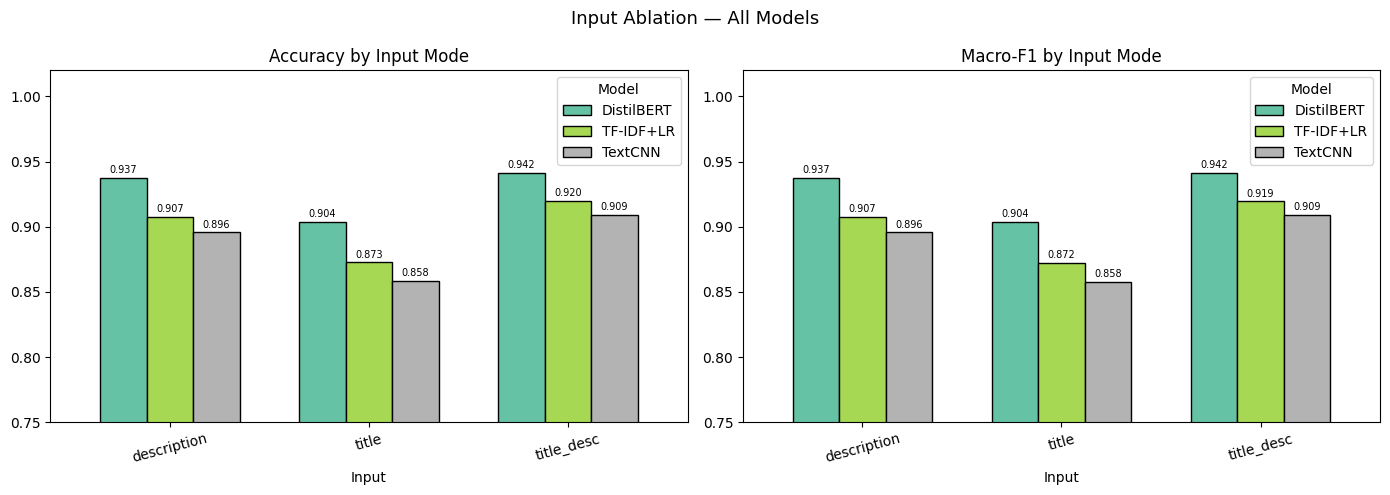

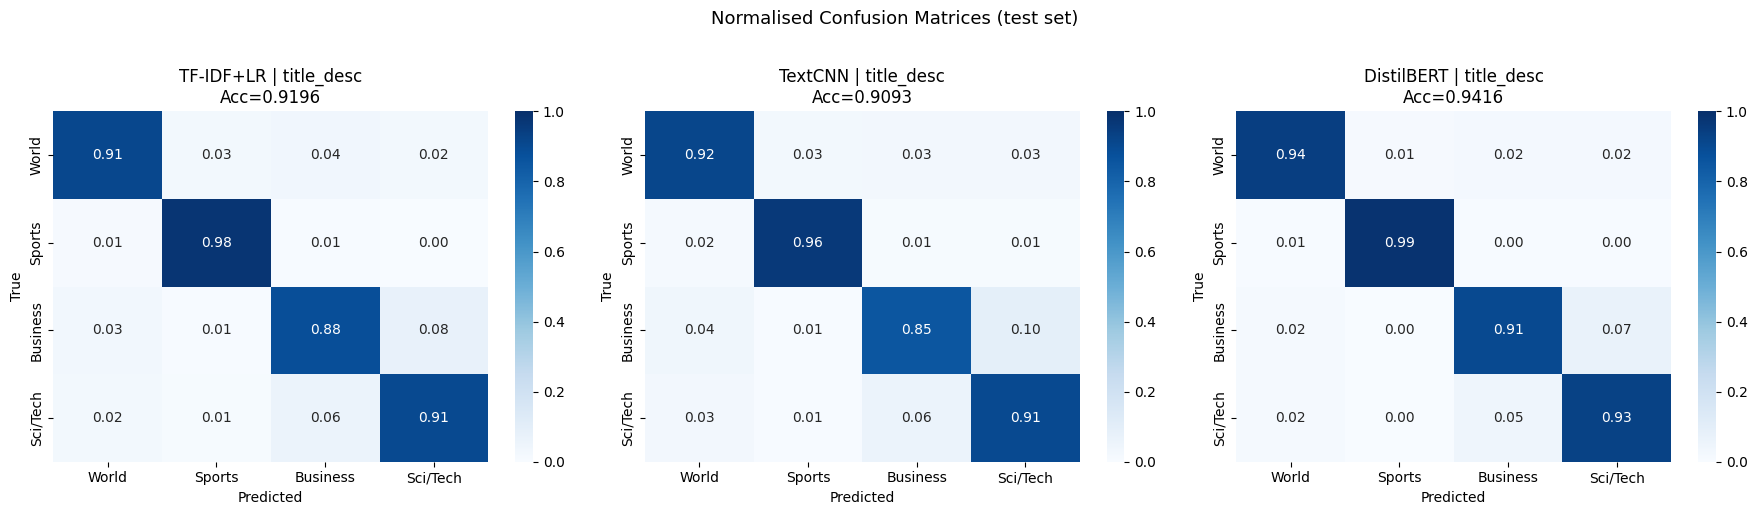

In [ ]:
# 자동 복구
if 'all_results' not in dir():
    raise RuntimeError("Cell 6 을 먼저 실행해 주세요.")

rows = []
for mode in INPUT_MODES:
    for mname in ['TF-IDF+LR', 'TextCNN', 'DistilBERT']:
        r = all_results[mname][mode]
        row = {'Model': mname, 'Input': mode,
               'Accuracy': r['acc'], 'Macro-F1': r['macro_f1']}
        for i, cls in enumerate(CLASSES):
            row[f'F1-{cls}'] = r['per_f1'][i]
        rows.append(row)

summary_df = pd.DataFrame(rows).round(4)
print(summary_df.to_string(index=False))

# Ablation bar plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ['Accuracy', 'Macro-F1']):
    pivot = summary_df.pivot(index='Input', columns='Model', values=metric)
    pivot.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black', width=0.7)
    ax.set_title(f'{metric} by Input Mode')
    ax.set_ylim(0.75, 1.02)
    ax.set_xticklabels(pivot.index, rotation=15)
    for c in ax.containers:
        ax.bar_label(c, fmt='%.3f', fontsize=7, padding=2)
plt.suptitle('Input Ablation — All Models', fontsize=13)
plt.tight_layout(); plt.show()

# Confusion matrices
_ensure_data()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, mname in zip(axes, ['TF-IDF+LR', 'TextCNN', 'DistilBERT']):
    r  = all_results[mname][TEXT_COL]
    cm = confusion_matrix(test_df[LABEL_COL], r['preds'])
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cmn, annot=True, fmt='.2f', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES,
                cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'{mname} | {TEXT_COL}\nAcc={r["acc"]:.4f}')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.suptitle('Normalised Confusion Matrices (test set)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


  Perturbation: baseline
    TF-IDF+LR   : Acc=0.9196  Macro-F1=0.9195
    TextCNN     : Acc=0.9093  Macro-F1=0.9092
    DistilBERT  : Acc=0.9416  Macro-F1=0.9416

  Perturbation: typos
    TF-IDF+LR   : Acc=0.9189  Macro-F1=0.9188
    TextCNN     : Acc=0.9068  Macro-F1=0.9067
    DistilBERT  : Acc=0.9405  Macro-F1=0.9405

  Perturbation: duplicate_words
    TF-IDF+LR   : Acc=0.9201  Macro-F1=0.9200
    TextCNN     : Acc=0.9054  Macro-F1=0.9053
    DistilBERT  : Acc=0.9405  Macro-F1=0.9405

  Perturbation: shuffled_sentences
    TF-IDF+LR   : Acc=0.9196  Macro-F1=0.9195
    TextCNN     : Acc=0.9092  Macro-F1=0.9091
    DistilBERT  : Acc=0.9417  Macro-F1=0.9417


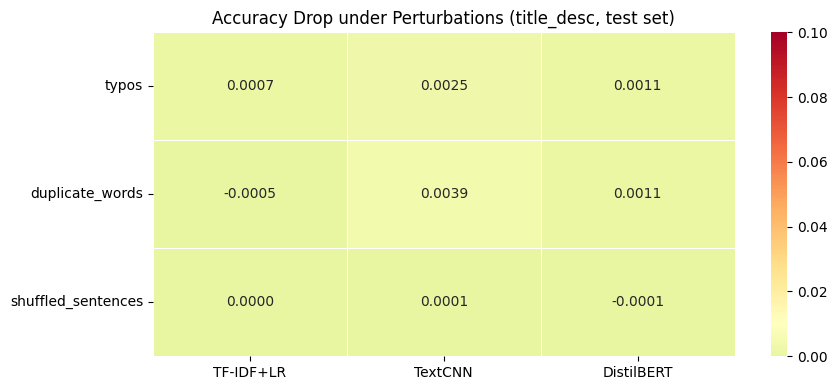

In [ ]:
_ensure_data(); _ensure_models()

def add_typos(text, n=1):
    if len(text) < 5: return text
    ws = text.split()
    for _ in range(n):
        if not ws: break
        wi = random.randrange(len(ws))
        chars = list(ws[wi])
        if not chars: continue
        ci = random.randrange(len(chars))
        if random.random() < 0.5: chars.pop(ci)
        else: chars.insert(ci, random.choice(string.ascii_lowercase))
        ws[wi] = ''.join(chars)
    return ' '.join(ws)

def dup_word(text, n=1):
    ws = text.split()
    for _ in range(n):
        if not ws: break
        wi = random.randrange(len(ws))
        ws.insert(wi, ws[wi])
    return ' '.join(ws)

def shuffle_sent(text):
    s = re.split(r'(?<=[.!?])\s+', text)
    random.shuffle(s)
    return ' '.join(s)

PERTURBATIONS = {
    'baseline':           lambda t: t,
    'typos':              add_typos,
    'duplicate_words':    dup_word,
    'shuffled_sentences': shuffle_sent,
}
all_perts = [p for p in PERTURBATIONS if p != 'baseline']

rob_results = {}
b = trained_models[TEXT_COL]
te_labels = test_df[LABEL_COL].tolist()

for pname, pfn in PERTURBATIONS.items():
    print(f"\n  Perturbation: {pname}")
    perturbed = [pfn(t) for t in test_df[TEXT_COL].tolist()]
    res = {}

    # TF-IDF+LR
    preds = b['tfidf'].predict(perturbed)
    res['TF-IDF+LR'] = (accuracy_score(te_labels, preds),
                         f1_score(te_labels, preds, average='macro'))

    # TextCNN
    r = predict_cnn(b['cnn'], perturbed, b['cnn_tok'], b['cnn_maxlen'])
    r = compute_metrics(te_labels, r['preds'])
    res['TextCNN'] = (r['acc'], r['macro_f1'])

    # DistilBERT
    r = predict_bert(b['bert'], perturbed, te_labels, get_probs=False)
    res['DistilBERT'] = (r['acc'], r['macro_f1'])

    rob_results[pname] = res
    for k, v in res.items():
        print(f"    {k:<12}: Acc={v[0]:.4f}  Macro-F1={v[1]:.4f}")

# Heatmap of accuracy drops
model_names = ['TF-IDF+LR', 'TextCNN', 'DistilBERT']
drop = np.zeros((len(all_perts), len(model_names)))
for i, pt in enumerate(all_perts):
    for j, mn in enumerate(model_names):
        drop[i, j] = rob_results['baseline'][mn][0] - rob_results[pt][mn][0]

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(drop, annot=True, fmt='.4f',
            xticklabels=model_names, yticklabels=all_perts,
            cmap='RdYlGn_r', center=0.01, vmin=0, vmax=0.1, linewidths=0.5)
ax.set_title(f'Accuracy Drop under Perturbations ({TEXT_COL}, test set)')
plt.tight_layout(); plt.show()

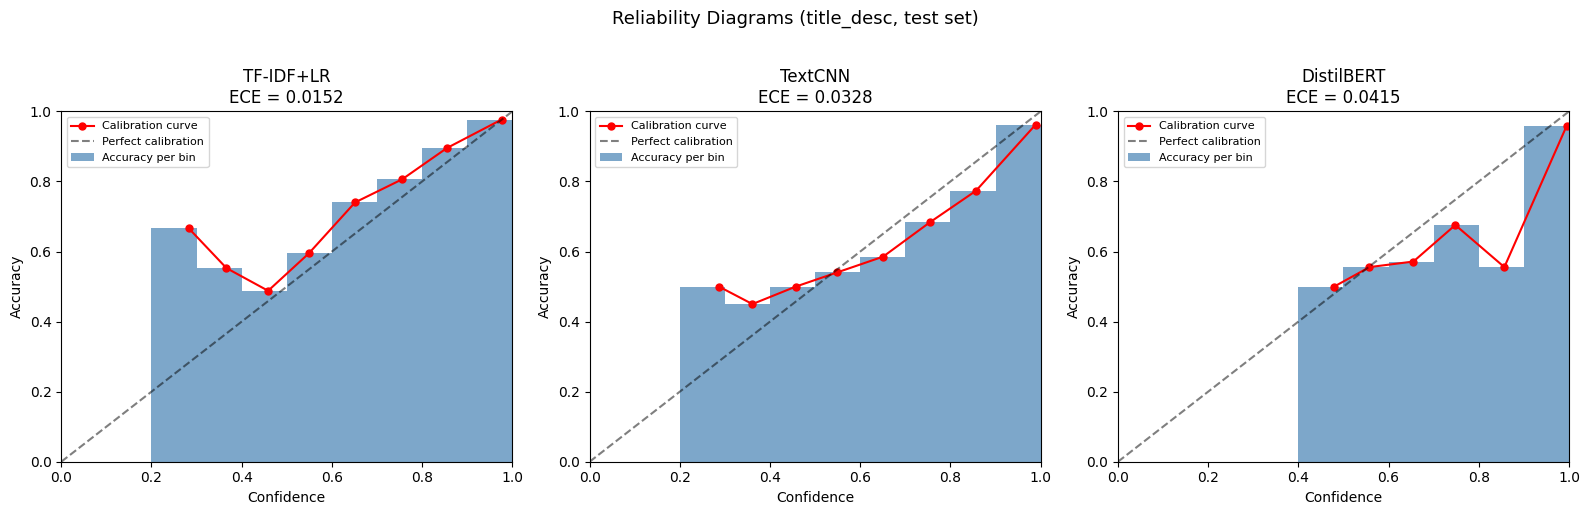


ECE Summary:
  TF-IDF+LR   : ECE = 0.0152
  TextCNN     : ECE = 0.0328
  DistilBERT  : ECE = 0.0415


In [ ]:
_ensure_data()
if 'trained_probs' not in dir() or 'TF-IDF+LR' not in trained_probs:
    print("⚠ trained_probs missing → recomputing from all_results ...")
    trained_probs = {
        'TF-IDF+LR' : all_results['TF-IDF+LR'][TEXT_COL]['probs'],
        'TextCNN'   : all_results['TextCNN'][TEXT_COL]['probs'],
        'DistilBERT': all_results['DistilBERT'][TEXT_COL]['probs'],
    }


def compute_ece(probs, labels, n_bins=10):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies  = (predictions == np.asarray(labels)).astype(float)
    edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0; bins = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (confidences > lo) & (confidences <= hi)
        if m.sum() > 0:
            a = accuracies[m].mean(); c = confidences[m].mean()
            ece += abs(a - c) * m.mean()
            bins.append((lo, hi, c, a))
    return ece, bins


true_labels_np = np.array(test_df[LABEL_COL].tolist())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (mname, probs) in zip(axes, trained_probs.items()):
    ece, bin_data = compute_ece(probs, true_labels_np)
    if bin_data:
        lo  = [b[0] for b in bin_data]
        w   = [b[1] - b[0] for b in bin_data]
        acc = [b[3] for b in bin_data]
        con = [b[2] for b in bin_data]
        ax.bar(lo, acc, width=w, align='edge', alpha=0.7, color='steelblue',
               label='Accuracy per bin')
        ax.plot(con, acc, 'ro-', ms=5, label='Calibration curve')
    ax.plot([0,1],[0,1], 'k--', alpha=0.5, label='Perfect calibration')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel('Confidence'); ax.set_ylabel('Accuracy')
    ax.set_title(f'{mname}\nECE = {ece:.4f}')
    ax.legend(fontsize=8)
plt.suptitle(f'Reliability Diagrams ({TEXT_COL}, test set)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print('\nECE Summary:')
ece_summary = {}
for mname, probs in trained_probs.items():
    ece, _ = compute_ece(probs, true_labels_np)
    ece_summary[mname] = ece
    print(f'  {mname:<12}: ECE = {ece:.4f}')

In [ ]:
_ensure_data(); _ensure_models()

# Topic keywords from training data (fast: TF-IDF class-mean approach)
kw_vect = TfidfVectorizer(ngram_range=(1,1), max_features=30_000, sublinear_tf=True)
X_kw    = kw_vect.fit_transform(train_df[TEXT_COL])
kw_feat = kw_vect.get_feature_names_out()

CLASS_KEYWORDS = {}
for cls_idx in range(NUM_CLASSES):
    mask = (train_df[LABEL_COL].values == cls_idx)
    mean_tfidf = X_kw[mask].mean(axis=0).A1
    top_idx = np.argsort(mean_tfidf)[-100:][::-1]
    CLASS_KEYWORDS[cls_idx] = set(kw_feat[top_idx])

def mask_keywords(text, kw_set, mask_token=''):
    # mask_token='' → 단어 제거 / '[MASK]' → 마스킹
    if mask_token:
        return ' '.join(mask_token if w.lower() in kw_set else w for w in text.split())
    return ' '.join(w for w in text.split() if w.lower() not in kw_set)

# ✅ rename() 호출 없이 masked 텍스트 리스트를 직접 만든다 (원본 ValueError 해결)
masked_texts = [
    mask_keywords(text, CLASS_KEYWORDS[label])
    for text, label in zip(test_df[TEXT_COL], test_df[LABEL_COL])
]
te_labels = test_df[LABEL_COL].tolist()
b = trained_models[TEXT_COL]

mask_results = {'baseline': {}, 'keyword': {}}

# Baseline = 이미 계산된 결과 사용
for mn in ['TF-IDF+LR', 'TextCNN', 'DistilBERT']:
    r = all_results[mn][TEXT_COL]
    mask_results['baseline'][mn] = (r['acc'], r['macro_f1'])

# Keyword-masked evaluation
print("\n  Keyword Masking (재학습 없음, 저장된 모델 사용):")

preds = b['tfidf'].predict(masked_texts)
mask_results['keyword']['TF-IDF+LR'] = (
    accuracy_score(te_labels, preds),
    f1_score(te_labels, preds, average='macro'))

r = predict_cnn(b['cnn'], masked_texts, b['cnn_tok'], b['cnn_maxlen'])
r = compute_metrics(te_labels, r['preds'])
mask_results['keyword']['TextCNN'] = (r['acc'], r['macro_f1'])

r = predict_bert(b['bert'], masked_texts, te_labels, get_probs=False)
mask_results['keyword']['DistilBERT'] = (r['acc'], r['macro_f1'])

for mn in ['TF-IDF+LR', 'TextCNN', 'DistilBERT']:
    base = mask_results['baseline'][mn][0]
    kw   = mask_results['keyword'][mn][0]
    print(f"    {mn:<12}: {base:.4f} → {kw:.4f}  (Δ={base-kw:+.4f})")


  Keyword Masking (재학습 없음, 저장된 모델 사용):
    TF-IDF+LR   : 0.9196 → 0.8457  (Δ=+0.0739)
    TextCNN     : 0.9093 → 0.8291  (Δ=+0.0803)
    DistilBERT  : 0.9416 → 0.8972  (Δ=+0.0443)


In [ ]:
# 모든 변수가 누락되었더라도 안전하게 메시지를 출력하도록 방어 코드 포함

print('=' * 70)
print('  FINAL SUMMARY — What Do Text Classifiers Learn?')
print('=' * 70)

# [1] Best input mode
if 'all_results' in dir():
    print('\n[1] Best Input Mode per Model (test set):')
    print(f"  {'Model':<12}  {'Best Input':<20}  {'Acc':>8}  {'Macro-F1':>10}")
    for mname in ['TF-IDF+LR', 'TextCNN', 'DistilBERT']:
        best = max(all_results[mname], key=lambda m: all_results[mname][m]['macro_f1'])
        r = all_results[mname][best]
        print(f"  {mname:<12}  {best:<20}  {r['acc']:>8.4f}  {r['macro_f1']:>10.4f}")

    # [2] title_desc 성능
    print(f'\n[2] {TEXT_COL} Performance:')
    h = f"  {'Model':<12}  {'Acc':>8}  {'Macro-F1':>10}"
    for cls in CLASSES: h += f"  {cls[:5]:>7}"
    print(h)
    for mname in ['TF-IDF+LR', 'TextCNN', 'DistilBERT']:
        r = all_results[mname][TEXT_COL]
        # ✅ KeyError 방지: per_f1 numpy 배열 직접 사용 (원본 r['report']['0'] 에러 해결)
        pf = r['per_f1']
        row = f"  {mname:<12}  {r['acc']:>8.4f}  {r['macro_f1']:>10.4f}"
        for v in pf: row += f"  {v:>7.4f}"
        print(row)
else:
    print('\n[1-2] all_results 가 없습니다. Cell 6 을 먼저 실행하세요.')

# [3] Robustness
if 'rob_results' in dir():
    print('\n[3] Robustness — Average Accuracy Drop per Perturbation:')
    model_names = ['TF-IDF+LR', 'TextCNN', 'DistilBERT']
    all_perts_local = [p for p in rob_results if p != 'baseline']
    for pt in all_perts_local:
        drops = [rob_results['baseline'][mn][0] - rob_results[pt][mn][0]
                 for mn in model_names]
        print(f"  {pt:<22}: avg_drop = {np.mean(drops):+.4f}")
else:
    print('\n[3] rob_results 가 없습니다. Cell 8 을 먼저 실행하세요.')

# [4] Calibration
if 'ece_summary' in dir():
    print('\n[4] Expected Calibration Error (test set):')
    for mname, v in ece_summary.items():
        print(f"  {mname:<12}: ECE = {v:.4f}")
else:
    print('\n[4] ece_summary 가 없습니다. Cell 9 를 먼저 실행하세요.')

# [5] Masking
if 'mask_results' in dir():
    print('\n[5] Keyword Masking — Accuracy Drop (topic-keyword reliance):')
    for mn in ['TF-IDF+LR', 'TextCNN', 'DistilBERT']:
        base = mask_results['baseline'][mn][0]
        kw   = mask_results['keyword'][mn][0]
        print(f"  {mn:<12}: {base:.4f} → {kw:.4f}  (Δ={base-kw:+.4f})")
else:
    print('\n[5] mask_results 가 없습니다. Cell 10 을 먼저 실행하세요.')

print('\n' + '=' * 70)
print('  All experiments complete.')
print('=' * 70)

  FINAL SUMMARY — What Do Text Classifiers Learn?

[1] Best Input Mode per Model (test set):
  Model         Best Input                 Acc    Macro-F1
  TF-IDF+LR     title_desc              0.9196      0.9195
  TextCNN       title_desc              0.9093      0.9092
  DistilBERT    title_desc              0.9416      0.9416

[2] title_desc Performance:
  Model              Acc    Macro-F1    World    Sport    Busin    Sci/T
  TF-IDF+LR       0.9196      0.9195   0.9196   0.9692   0.8878   0.9012
  TextCNN         0.9093      0.9092   0.9138   0.9616   0.8754   0.8861
  DistilBERT      0.9416      0.9416   0.9509   0.9832   0.9144   0.9178

[3] Robustness — Average Accuracy Drop per Perturbation:
  typos                 : avg_drop = +0.0014
  duplicate_words       : avg_drop = +0.0015
  shuffled_sentences    : avg_drop = +0.0000

[4] Expected Calibration Error (test set):
  TF-IDF+LR   : ECE = 0.0152
  TextCNN     : ECE = 0.0328
  DistilBERT  : ECE = 0.0415

[5] Keyword Masking — Acc